Train shape: (242, 20)  Test shape: (61, 20)


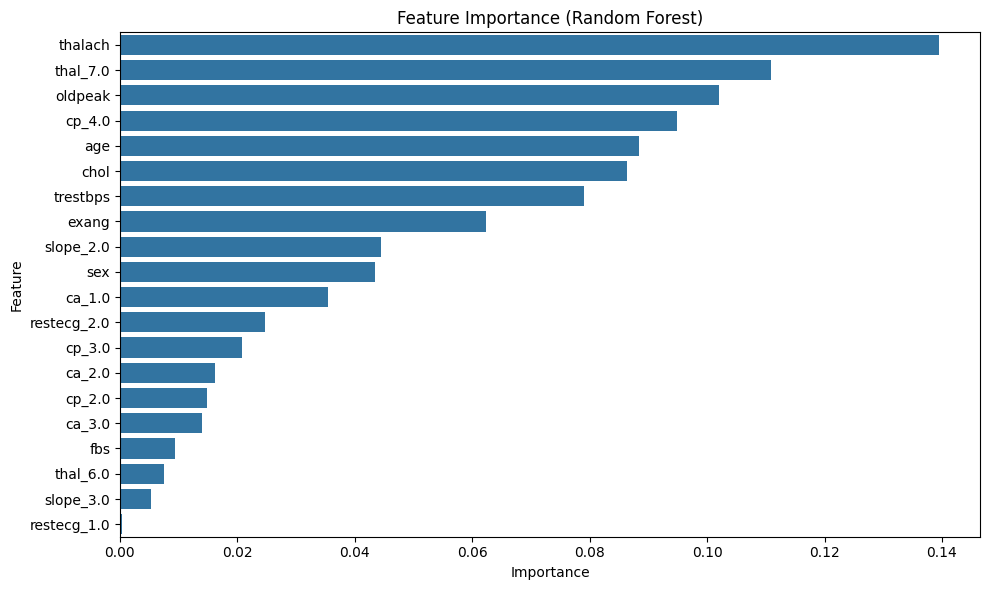

RFE selected features: ['sex', 'trestbps', 'cp_4.0', 'slope_2.0', 'thal_7.0', 'ca_1.0', 'ca_2.0', 'ca_3.0']
Chi-Square selected features: ['exang', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'slope_2.0', 'thal_7.0', 'ca_1.0', 'ca_2.0']


In [ ]:
# 03 - Feature Selection (unchanged core logic; no pipeline needed here)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE, SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# 1) Load cleaned dataset and prepare target
df = pd.read_csv("../data/heart_disease_cleaned.csv")
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# 2) Random Forest Feature Importance
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = np.array(X_train.columns)[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names, orient="h")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 3) Recursive Feature Elimination (RFE) with Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
rfe = RFE(log_reg, n_features_to_select=8)
rfe.fit(X_train, y_train)
rfe_selected = X_train.columns[rfe.support_].tolist()
print("RFE selected features:", rfe_selected)

# 4) Chi-Square (requires non-negative features)
scaler_minmax = MinMaxScaler()
X_train_mm = scaler_minmax.fit_transform(X_train)
selector = SelectKBest(score_func=chi2, k=8)
selector.fit(X_train_mm, y_train)
chi2_selected = X_train.columns[selector.get_support()].tolist()
print("Chi-Square selected features:", chi2_selected)